#### 案例：演示聚类算法的评估指标，即：SSE + 肘部法，SC轮廓系数法，CH轮廓系数法
 
聚类算法的评估指标：

    思路1：SSE + 肘部法
        SSE：
            概述：
                所有簇的 所有样本到该簇质心的 误差的平方和。
            特点：
                随着K值的增加，SSE值会逐渐减少
            目标：
                SSE值越小，代表簇内样本越聚集，内聚程度越高。
        肘部法：
            K值增大，SSE值会随之减小，下降梯度陡然变缓的时候，那个K值，就是我们要的最佳值。
            
    思路2：SC轮廓系数
        考虑簇内 -> 聚集程度，越小越好
        考虑簇外 -> 分离程度，越大越好
        轮廓系数 = (簇外距离 - 簇内距离) / max(簇内距离, 簇外距离)
        轮廓系数的取值范围：[-1, 1]
            轮廓系数越接近1，代表聚类效果越好；轮廓系数越接近-1，代表聚类效果越差；轮廓系数接近0，代表样本处于两个簇的边界上。
            
    思路3：CH轮廓系数
        考虑簇内 -> 聚集程度，越小越好
        考虑簇外 -> 分离程度，越大越好
        考虑K值 -> K值越大，代表簇内样本越聚集，内聚程度越高
        

In [1]:
+import os
os.environ['OMP_NUM_THREADS'] = '4'         # OpenMP多任务程序, 这里设置为4个线程, 防止出现线程冲突等.

#### 导包

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import silhouette_score

#### 1. 定义函数，演示： SSE + 肘部法

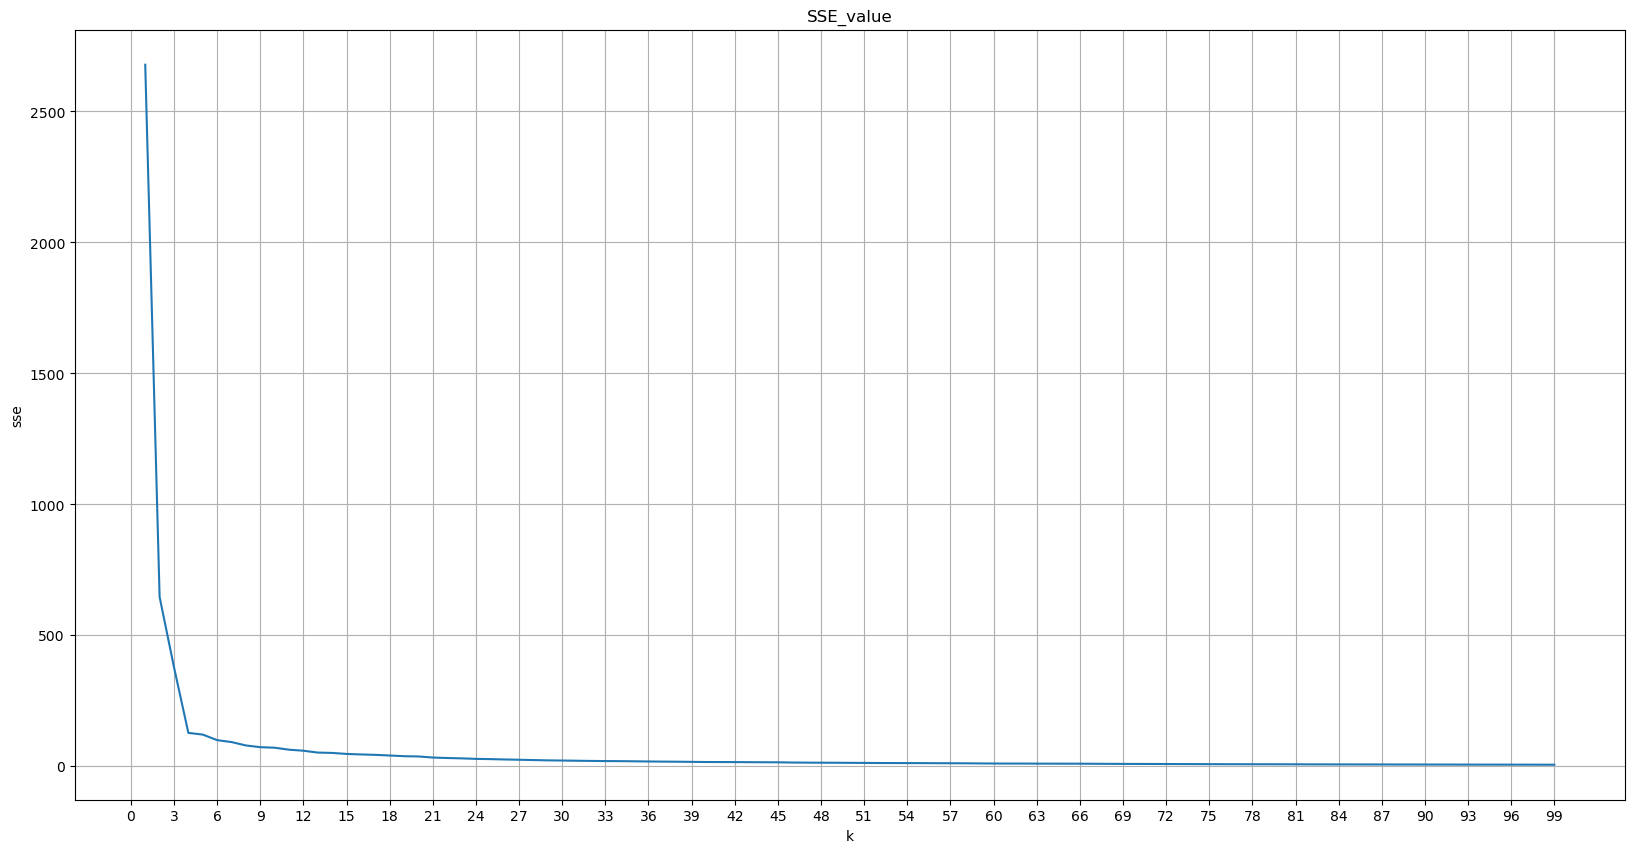

In [10]:
def dm01_sse():
    # 1. 定义sse列表，记录：每个k值对应的SSE值
    sse_list = []
    
    # 2. 生成数据集
    # 参1：样本数量；参2：特征数量；参3：中心点坐标；参4：簇的标准差；参5：随机数种子
    x, y = make_blobs(
        n_samples=1000,
        n_features=2,
        centers=[[-1, -1], [0, 0], [1, 1], [2, 2]],
        cluster_std=[0.4, 0.2, 0.2, 0.2], 
        random_state=23
    )
    
    # 3. for训练遍历，获取到每个k值，计算其对应的SSE值，并记录到sse_list列表中
    for k in range(1, 100):
        # 3.1 创建KMeans对象，设置k值
        # 参1：簇的数量；参2：最大迭代次数；参3：随机数种子
        estimator = KMeans(n_clusters=k, max_iter=100, random_state=23)
        # 3.2 训练模型
        estimator.fit(x)
        # 3.3 模型预测
        # 3.4 获取到每个簇的sse值
        sse_value = estimator.inertia_
        # 3.5 将每个k值对应的sse值，添加到sse_list列表中
        sse_list.append(sse_value)
        
    # 4. 绘制SSE曲线 -> 数据的可视化
    # print(sse_list)
    # 4.1 创建画布，设置画布尺寸
    plt.figure(figsize=(20, 10))
    # 4.2 设置标题
    plt.title('SSE_value')
    # 4.3 设置x轴的刻度
    # range(0, 100, 3) -> 从0开始，到100结束，步长为3
    plt.xticks(range(0, 100, 3))
    # 4.4 添加x轴和y轴的标签
    plt.xlabel('k')
    plt.ylabel('sse')
    # 4.5 绘制网格
    plt.grid()
    # 4.6 绘制折线图
    # 参1：k值；参2：该k值对应的sse值
    plt.plot(range(1, 100), sse_list)    
    plt.show()
    
    
    
dm01_sse()

#### 2. 定义函数，演示： SC轮廓系数法

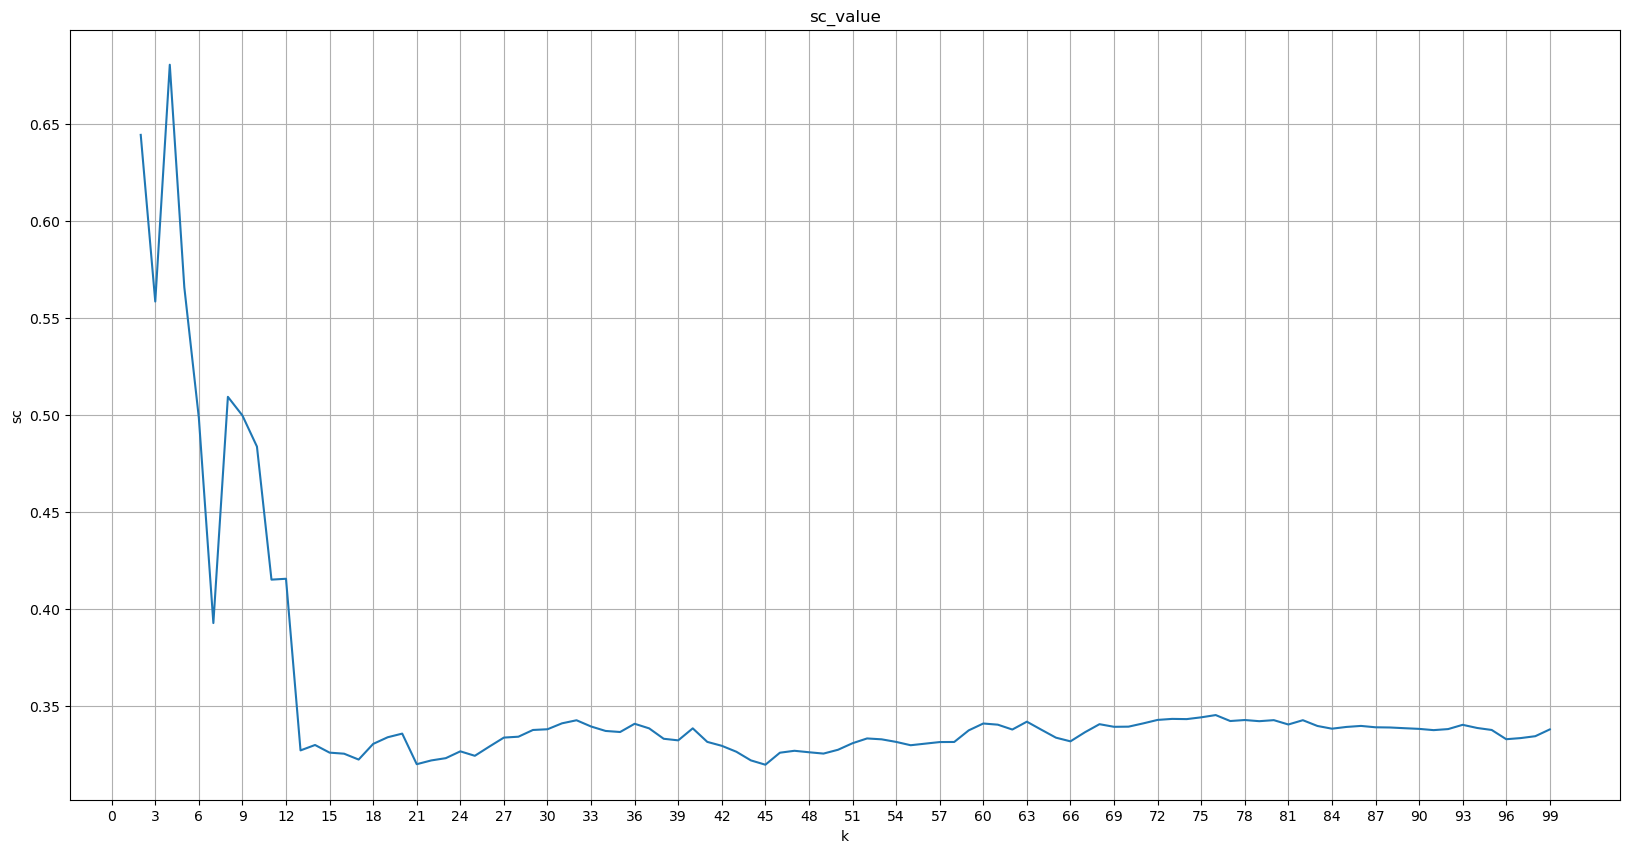

In [11]:
def dm02_sc():
    # 1. 定义sc列表，记录：每个k值对应的sc值
    sc_list = []
    
    # 2. 生成数据集
    # 参1：样本数量；参2：特征数量；参3：中心点坐标；参4：簇的标准差；参5：随机数种子
    x, y = make_blobs(
        n_samples=1000,
        n_features=2,
        centers=[[-1, -1], [0, 0], [1, 1], [2, 2]],
        cluster_std=[0.4, 0.2, 0.2, 0.2], 
        random_state=23
    )
    
    # 3. for训练遍历，获取到每个k值，计算其对应的sc值，并记录到sc_list列表中
    for k in range(2, 100):         # 考虑簇外，至少要有两个簇，所以k值从2开始
        # 3.1 创建KMeans对象，设置k值
        # 参1：簇的数量；参2：最大迭代次数；参3：随机数种子
        estimator = KMeans(n_clusters=k, max_iter=100, random_state=23)
        # 3.2 训练模型
        estimator.fit(x)
        # 3.3 模型预测
        y_pred = estimator.predict(x)
        # 3.4 获取到每个簇的sc值
        sc_value = silhouette_score(x, y_pred)
        # 3.5 将每个k值对应的sc值，添加到sc_list列表中
        sc_list.append(sc_value)
        
    # 4. 绘制sc曲线 -> 数据的可视化
    # print(sc_list)
    # 4.1 创建画布，设置画布尺寸
    plt.figure(figsize=(20, 10))
    # 4.2 设置标题
    plt.title('sc_value')
    # 4.3 设置x轴的刻度
    # range(0, 100, 3) -> 从0开始，到100结束，步长为3
    plt.xticks(range(0, 100, 3))
    # 4.4 添加x轴和y轴的标签
    plt.xlabel('k')
    plt.ylabel('sc')
    # 4.5 绘制网格
    plt.grid()
    # 4.6 绘制折线图
    # 参1：k值；参2：该k值对应的sc值
    plt.plot(range(2, 100), sc_list)    
    plt.show()
    
    
    
dm02_sc()

#### 3. 定义函数，演示： CH轮廓系数法

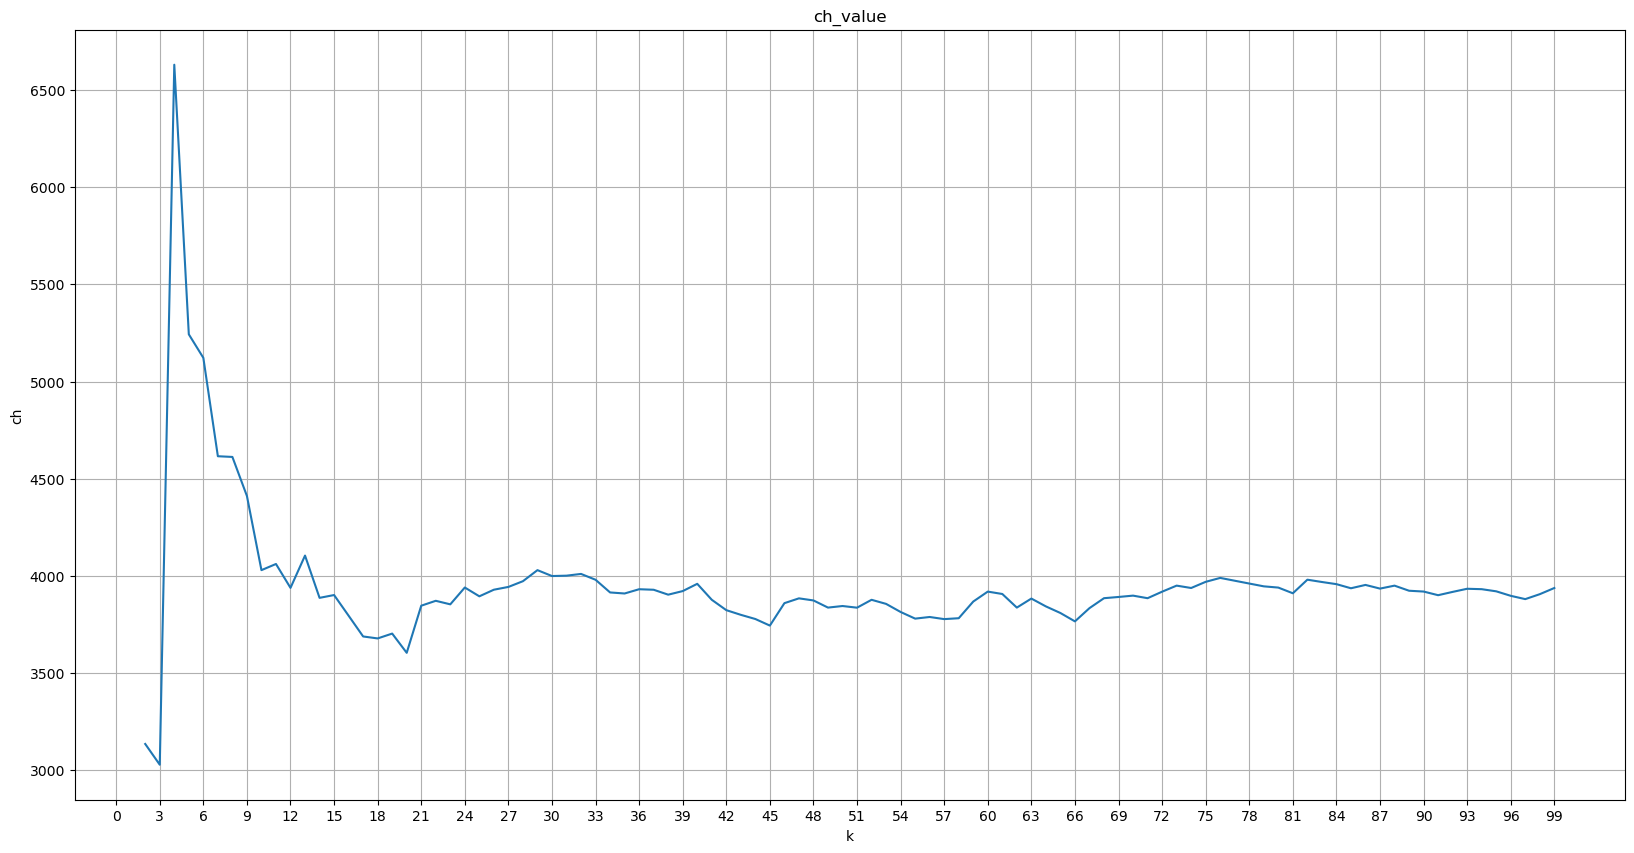

In [12]:
def dm03_ch():
    # 1. 定义ch列表，记录：每个k值对应的ch值
    ch_list = []
    
    # 2. 生成数据集
    # 参1：样本数量；参2：特征数量；参3：中心点坐标；参4：簇的标准差；参5：随机数种子
    x, y = make_blobs(
        n_samples=1000,
        n_features=2,
        centers=[[-1, -1], [0, 0], [1, 1], [2, 2]],
        cluster_std=[0.4, 0.2, 0.2, 0.2], 
        random_state=23
    )
    
    # 3. for训练遍历，获取到每个k值，计算其对应的ch值，并记录到ch_list列表中
    for k in range(2, 100):         # 考虑簇外，至少要有两个簇，所以k值从2开始
        # 3.1 创建KMeans对象，设置k值
        # 参1：簇的数量；参2：最大迭代次数；参3：随机数种子
        estimator = KMeans(n_clusters=k, max_iter=100, random_state=23)
        # 3.2 训练模型
        estimator.fit(x)
        # 3.3 模型预测
        y_pred = estimator.predict(x)
        # 3.4 获取到每个簇的ch值
        ch_value = calinski_harabasz_score(x, y_pred)
        # 3.5 将每个k值对应的ch值，添加到ch_list列表中
        ch_list.append(ch_value)
        
    # 4. 绘制ch曲线 -> 数据的可视化
    # print(ch_list)
    # 4.1 创建画布，设置画布尺寸
    plt.figure(figsize=(20, 10))
    # 4.2 设置标题
    plt.title('ch_value')
    # 4.3 设置x轴的刻度
    # range(0, 100, 3) -> 从0开始，到100结束，步长为3
    plt.xticks(range(0, 100, 3))
    # 4.4 添加x轴和y轴的标签
    plt.xlabel('k')
    plt.ylabel('ch')
    # 4.5 绘制网格
    plt.grid()
    # 4.6 绘制折线图
    # 参1：k值；参2：该k值对应的ch值
    plt.plot(range(2, 100), ch_list)    
    plt.show()
    
    
    
dm03_ch()